In [2]:
import pyarrow
import pandas as pd
import sqlite3
import numpy
import geopandas
import geopy
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import xgboost
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import tabulate

In [2]:
df= pd.read_parquet("ceny_mieszkan_v1.parquet")

### cena za m2 a powierzchnia

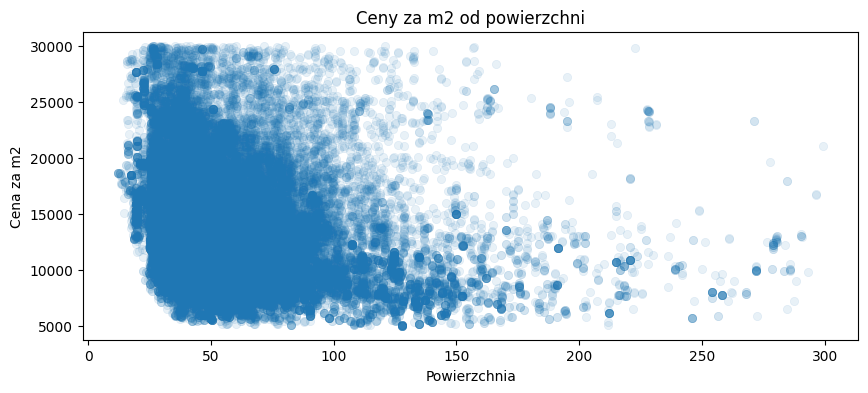

In [3]:
plt.figure(figsize=(10,4))
sns.scatterplot( data=df[df["area"]<300],
    x="area",
    y="price_m2",

    alpha=0.1,  #wypełnienie
    edgecolor=None,   
)

plt.xlabel("Powierzchnia")
plt.ylabel("Cena za m2")
plt.title("Ceny za m2 od powierzchni")

plt.show()


Kropki nakładają się na siebie, jakieś zależności widać, ale nie jest to czytelne.

Proponuję policzyć średnią cenę za metr kwadratowy mieszkania. Ale że mieszkania są różnej wielkości (np. 45m2, 45.1m2, 45.2m2) to zaokrąglimy ich powierzchnię do wartości całkowitych. Policzymy też ile jest tych ofert.

In [4]:
plot_df = df[df["area"]<300][["area","price_m2"]].copy()

In [5]:
plot_df["area"] = plot_df["area"].round(0)

In [6]:
plot_df = (
    plot_df
    .groupby("area", as_index=False)
    .agg(
        price_m2_mean= ("price_m2", "mean"),
        price_m2_count= ("price_m2", "count")
    ))

## Wykres na tej podstawie

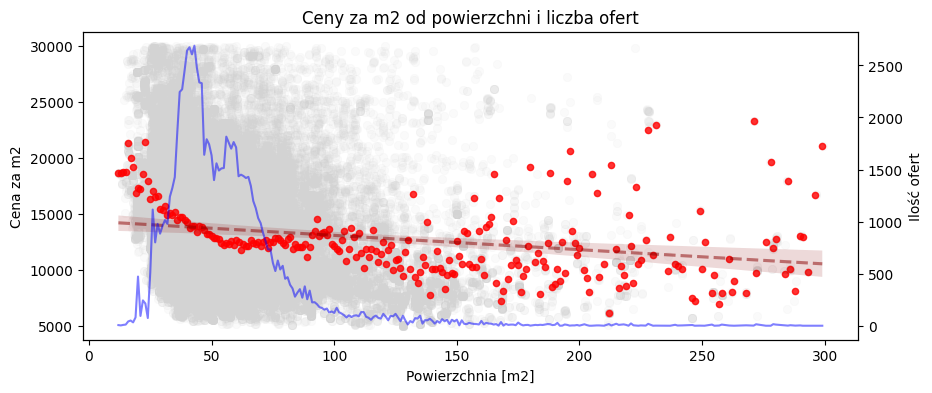

In [7]:
plt.figure(figsize=(10,4))

# Tworzenie osi
ax1 = plt.gca() #pobranie głównej osi
ax2 = ax1.twinx()   #stwórz bliźniaczą oś - nowa skala

sns.scatterplot( data=df[df["area"]<300],
    x="area",
    y="price_m2",

    alpha=0.1,  #wypełnienie
    edgecolor=None,
    color='lightgray',
    ax=ax1     
)

sns.regplot(
    data=plot_df,
    x="area",
    y="price_m2_mean",
    color='red',
    line_kws={"color": "darkred",
             "linestyle": "--",
             "alpha": 0.5},
    scatter_kws={"s": 20,
                 "color": "red"},
    ax = ax1,
)

sns.lineplot(
    data=plot_df,
    x="area",
    y="price_m2_count",
    ax=ax2, 
    color='blue',
    alpha=0.5
)


ax1.set_xlabel("Powierzchnia [m2]")
ax1.set_ylabel("Cena za m2")
ax2.set_ylabel("Ilość ofert")


plt.title("Ceny za m2 od powierzchni i liczba ofert")

plt.show()

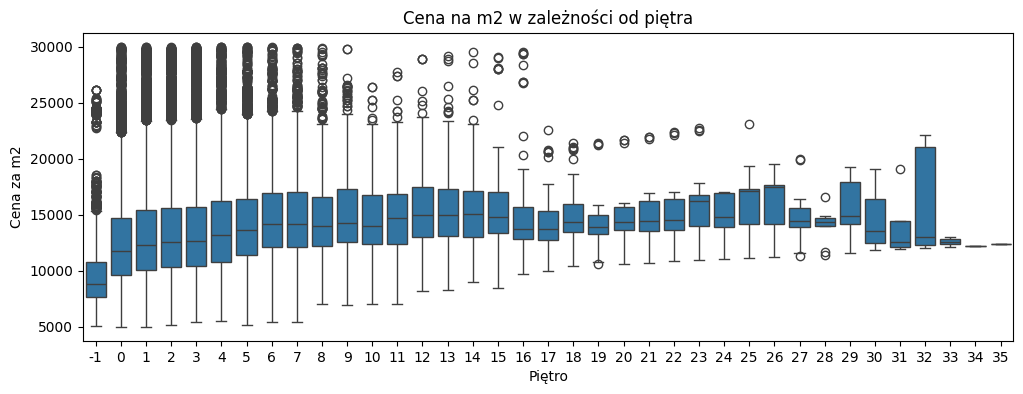

In [11]:
df["floor"] = df["floor"].astype(int)

plt.figure(figsize=(12, 4))
sns.boxplot(data=df,
            x="floor",
            y="price_m2")
plt.title("Cena na m2 w zależności od piętra")
plt.xlabel("Piętro")
plt.ylabel("Cena za m2")
plt.show()

Sprawdzamy maksymalne piętro

In [10]:
df["floor_max"] = df.groupby(["city","developer","investment"])["floor"].transform("max")

Text(0, 0.5, 'Cena za m2')

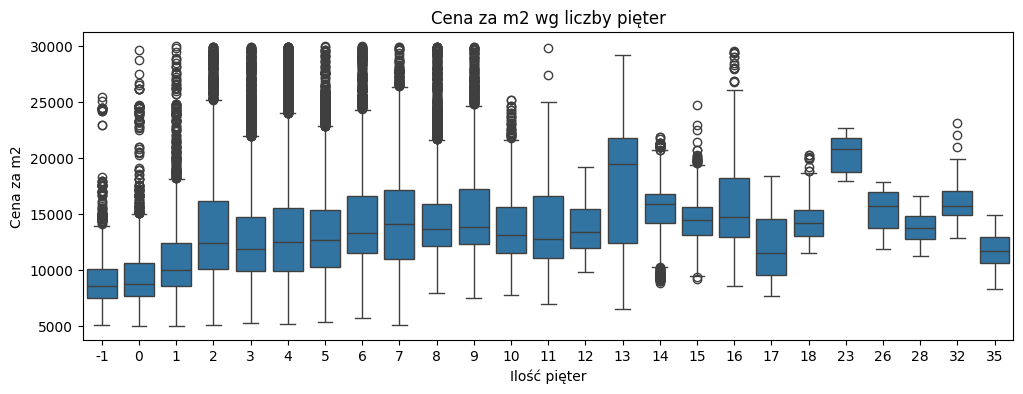

In [12]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df,
            x="floor_max",
            y="price_m2")
plt.title("Cena za m2 wg liczby pięter")
plt.xlabel("Ilość pięter")
plt.ylabel("Cena za m2")

Dodajmy cechę mówiącą czy lokal jest na ostatnim piętrze i sprawdźmy czy to ma znaczenie:

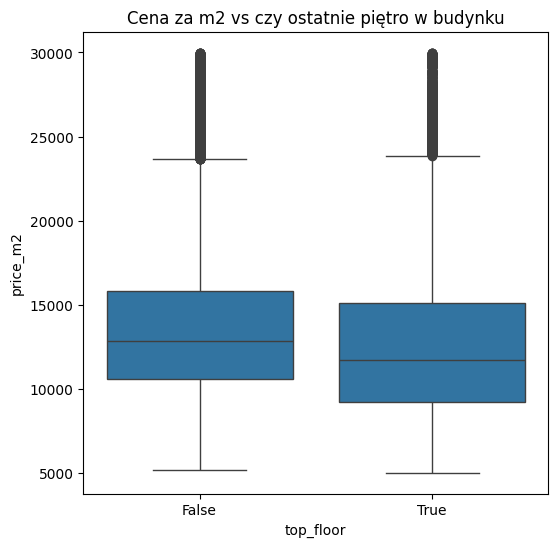

In [13]:

df["top_floor"] = df["floor"] == df["floor_max"]

plt.figure(figsize=(6, 6))
sns.boxplot(data=df,
            x="top_floor",
            y="price_m2")
plt.title("Cena za m2 vs czy ostatnie piętro w budynku")
plt.show()

In [17]:
df["has_balcony"] = df["balcony"].apply(lambda x: 1 if x > 0 else 0)
df["has_loggia"] = df["loggia"].apply(lambda x: 1 if x > 0 else 0)
df["has_terrace"] = df["terrace"].apply(lambda x: 1 if x > 0 else 0)
df["has_garden"] = df["garden"].apply(lambda x: 1 if x > 0 else 0)

df["balcony_and_loggia"] = df["balcony"] + df["loggia"]
df["terrace_and_garden"] = df["terrace"] + df["garden"]

In [18]:

for c in ["has_balcony", "has_loggia", "has_terrace", "has_garden"]:
    print(df \
            .groupby(c)["price_m2"] \
            .mean() \
            .to_markdown(),
            end="\n\n")

|   has_balcony |   price_m2 |
|--------------:|-----------:|
|             0 |    13319.1 |
|             1 |    13520.4 |

|   has_loggia |   price_m2 |
|-------------:|-----------:|
|            0 |    13374.9 |
|            1 |    13637.6 |

|   has_terrace |   price_m2 |
|--------------:|-----------:|
|             0 |    13423.1 |
|             1 |    12985.3 |

|   has_garden |   price_m2 |
|-------------:|-----------:|
|            0 |    13520.8 |
|            1 |    12235.9 |



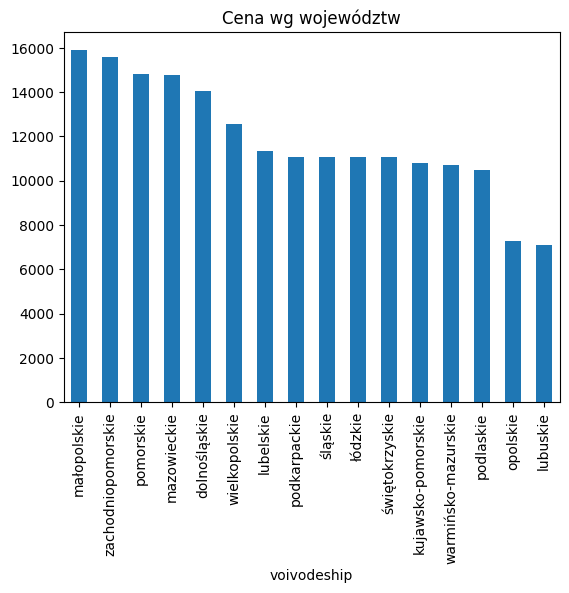

In [20]:
avg_price_voivodeship = (
    df
    .groupby("voivodeship")["price_m2"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_voivodeship.plot(kind="bar")

plt.title("Cena wg województw")
plt.show()


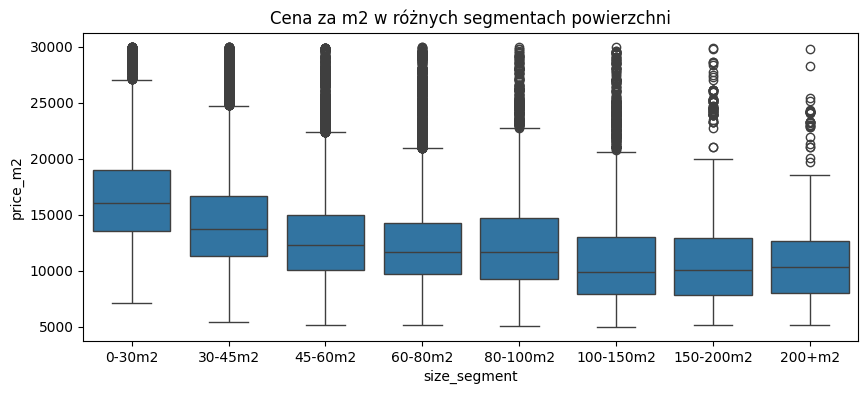

In [21]:

# przykład przedziałów powierzchni
bins = [0, 30, 45, 60, 80, 100, 150, 200, 10_000]
labels = [
    "0-30m2",
    "30-45m2",
    "45-60m2",
    "60-80m2",
    "80-100m2",
    "100-150m2",
    "150-200m2",
    "200+m2",
]

# przypisane do przedziału
df["size_segment"] = pd.cut(df["area"],
            bins=bins,
            labels=labels)

# nasz wykres
plt.figure(figsize=(10, 4))
sns.boxplot(data=df,
            x="size_segment",
            y="price_m2")
plt.title("Cena za m2 w różnych segmentach powierzchni")
plt.show()


In [22]:

df.to_parquet("ceny_mieszkan_v2.parquet", index=False)


In [3]:
df = pd.read_parquet("ceny_mieszkan_v2.parquet")

Text(0.5, 1.0, 'Ceny developerów w: lubuskie')

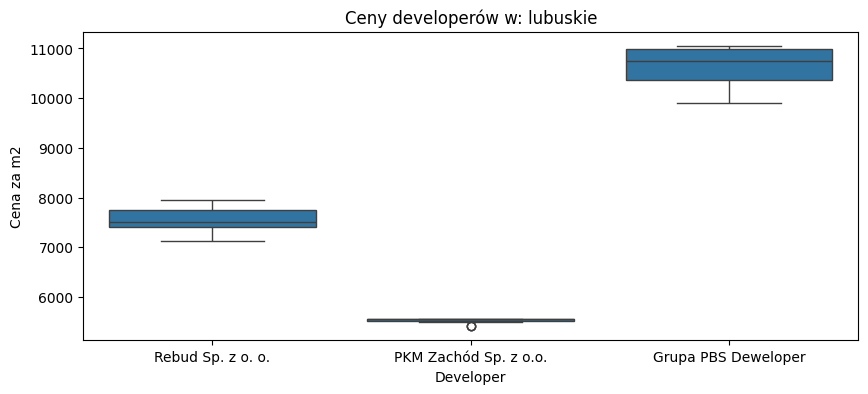

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(
    data=df[df["voivodeship"]=="lubuskie"],
    x= "developer",
    y="price_m2"
)

plt.xlabel("Developer")
plt.ylabel("Cena za m2")
plt.title("Ceny developerów w: "+"lubuskie")
plt.show()

In [13]:
df[["voivodeship","developer"]].groupby("voivodeship", as_index=False).nunique()#["voivodeship"]


,voivodeship,developer
0,dolnośląskie,120
1,kujawsko-pomorskie,57
2,lubelskie,40
3,lubuskie,3
4,mazowieckie,254
5,małopolskie,145
6,opolskie,5
7,podkarpackie,22
8,podlaskie,25
9,pomorskie,126


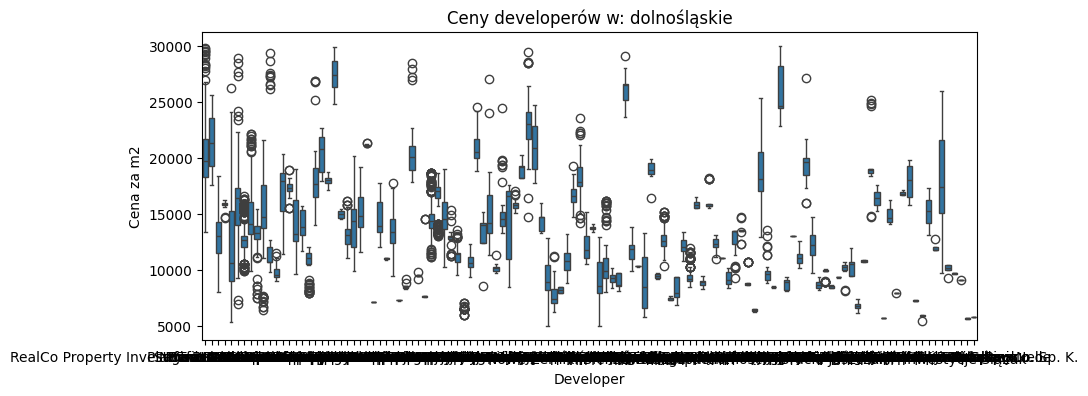

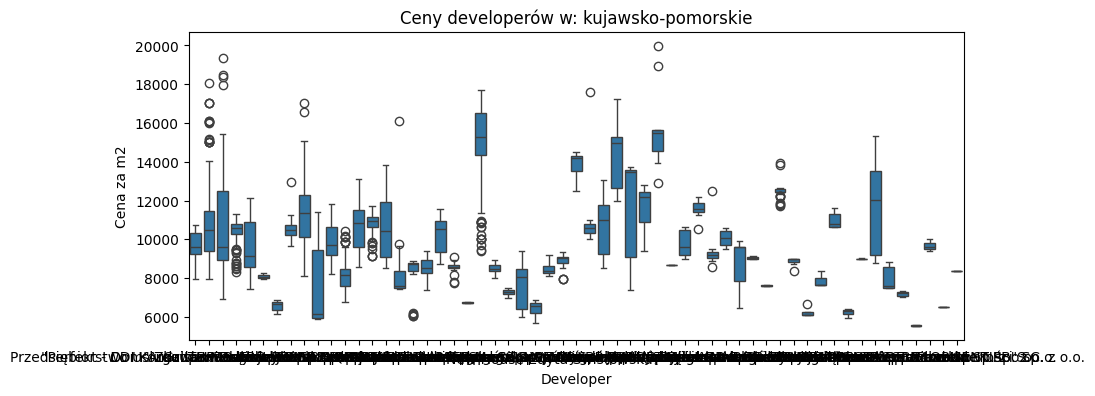

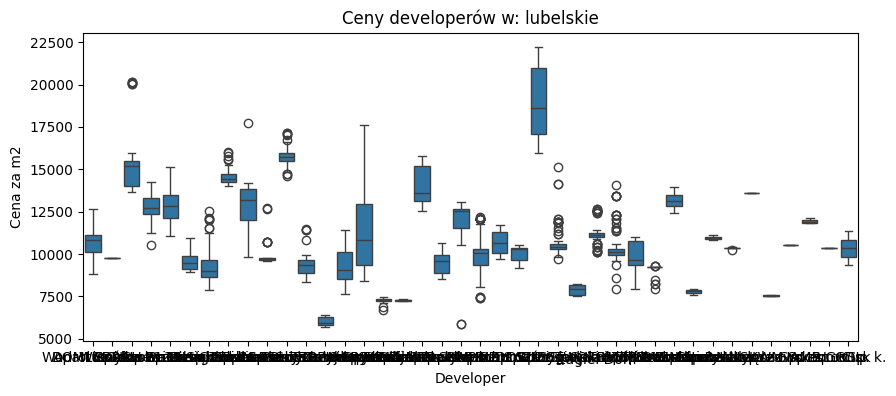

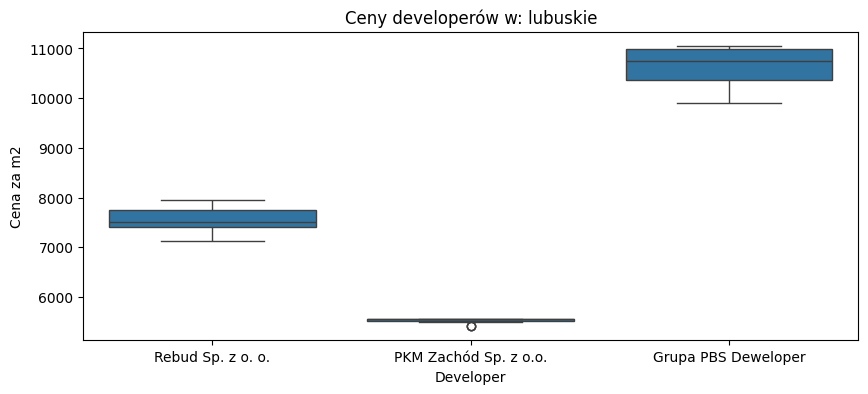

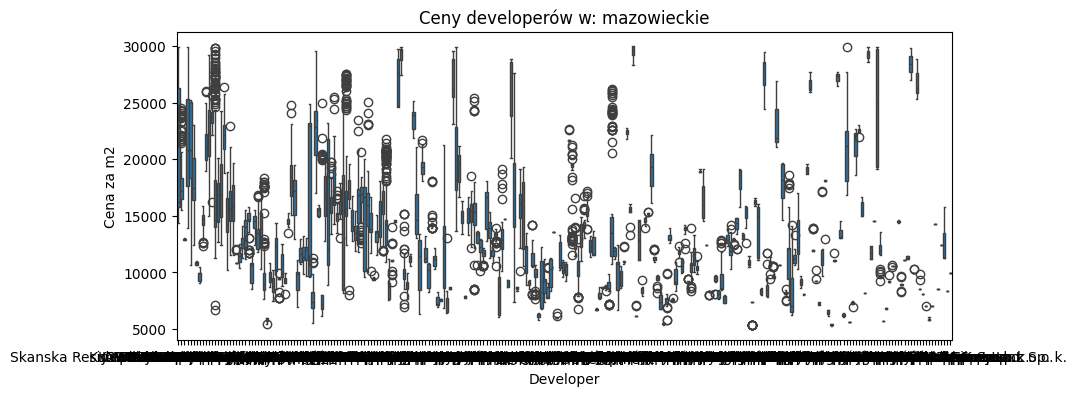

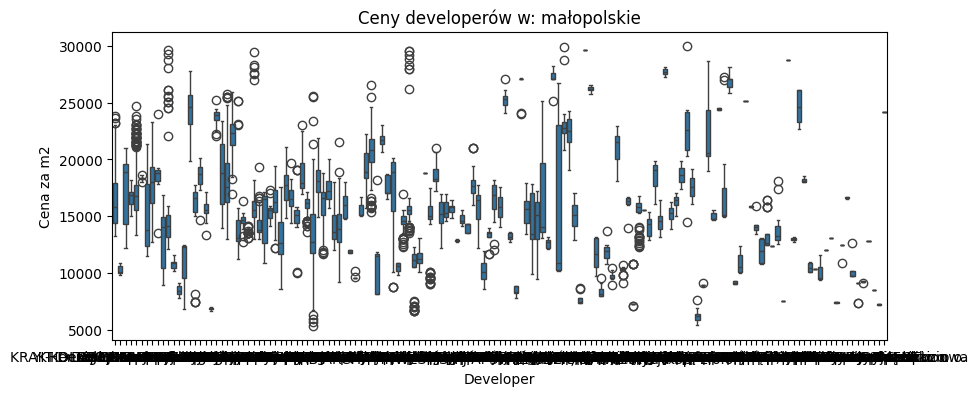

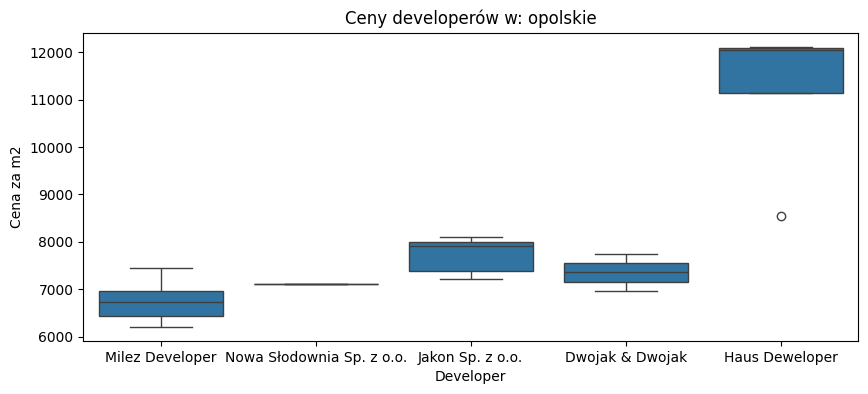

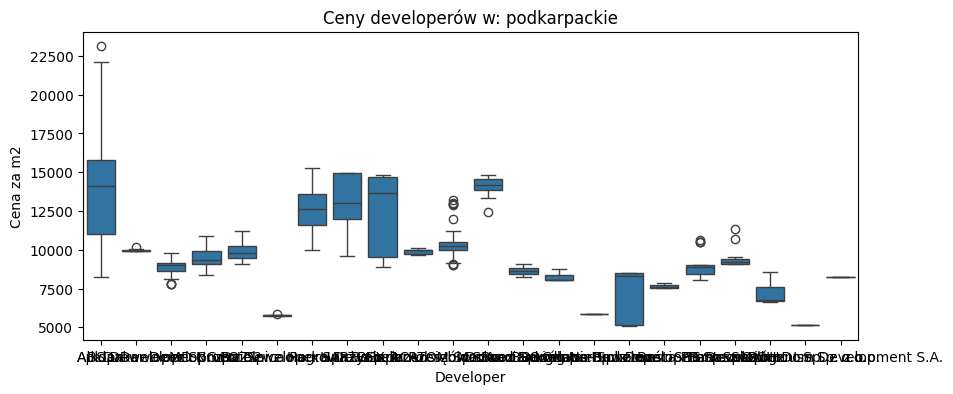

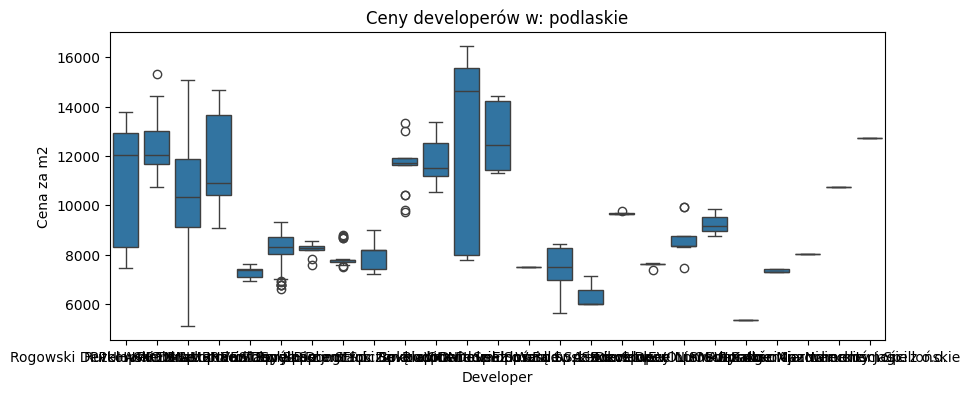

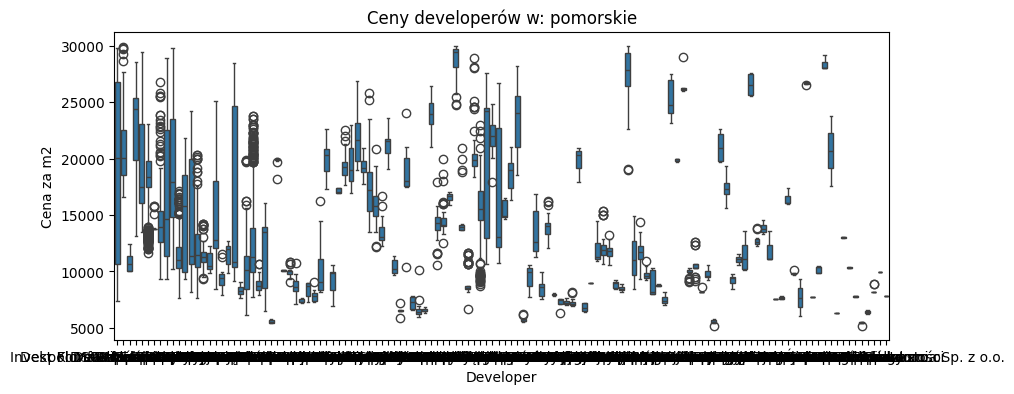

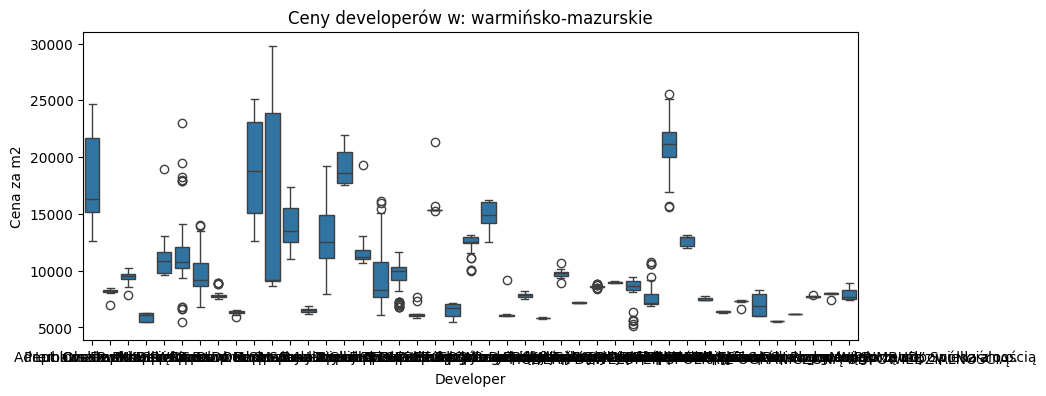

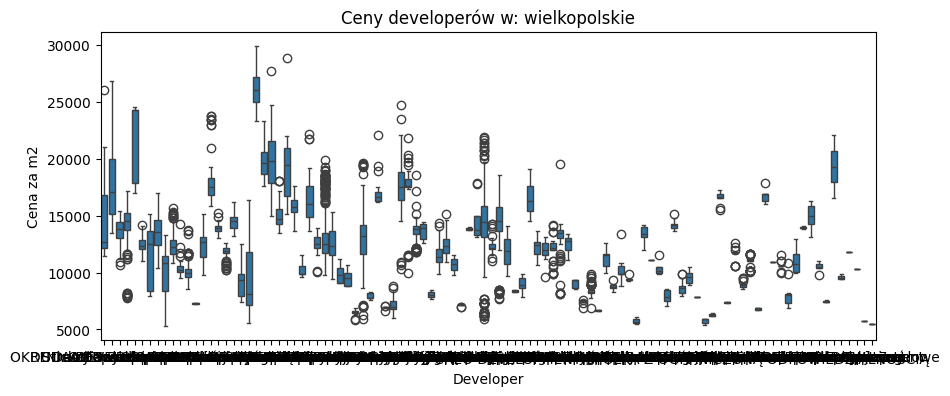

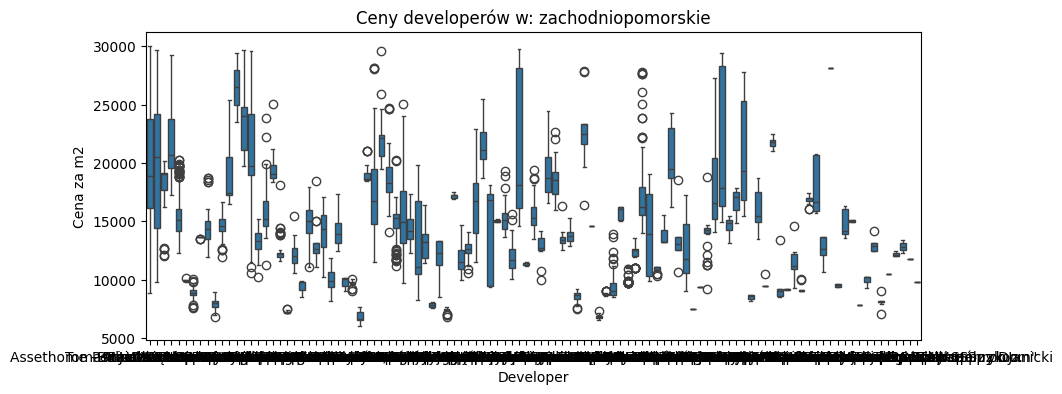

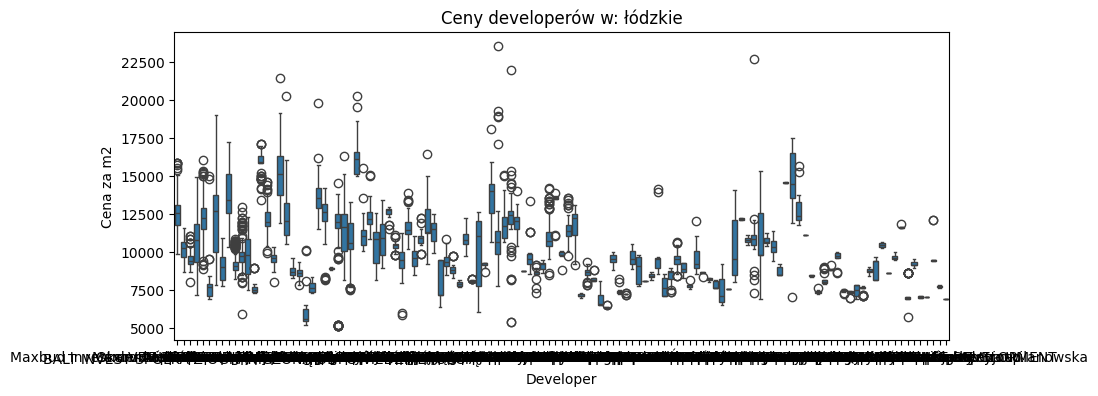

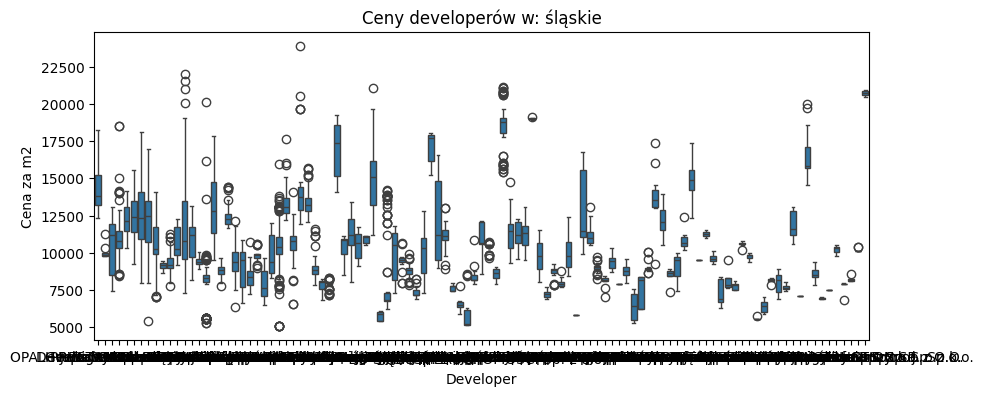

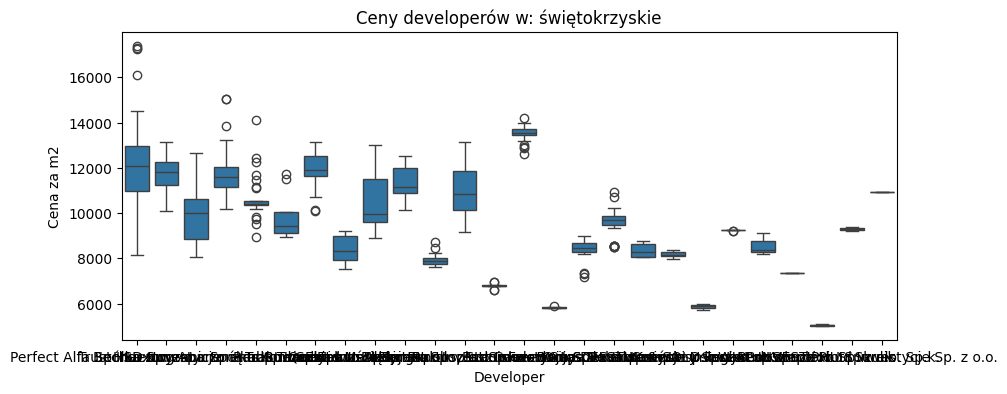

In [17]:
for voivodeship in df[["voivodeship","developer"]].groupby("voivodeship", as_index=False).nunique()["voivodeship"]:
    plt.figure(figsize=(10,4))
    sns.boxplot(
        data=df[df["voivodeship"]==voivodeship],
        x= "developer",
        y="price_m2"
    )

    plt.xlabel("Developer")
    plt.ylabel("Cena za m2")
    plt.title("Ceny developerów w: "+voivodeship)
    plt.show()

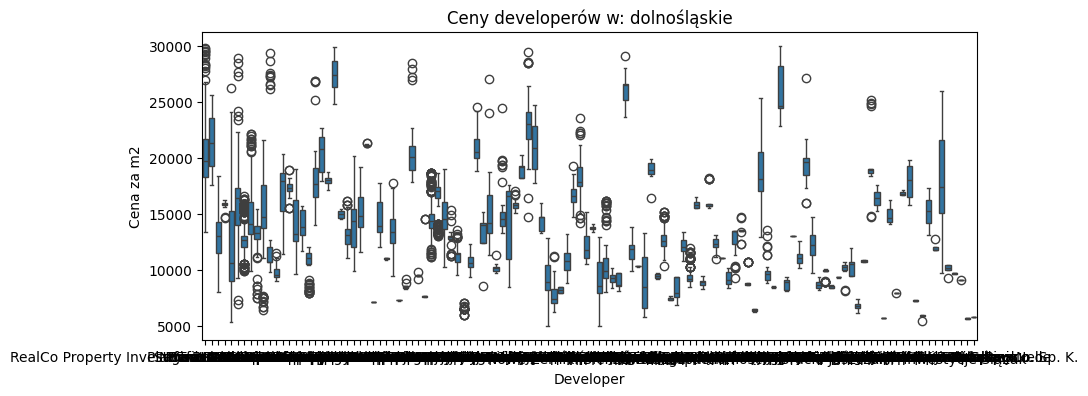

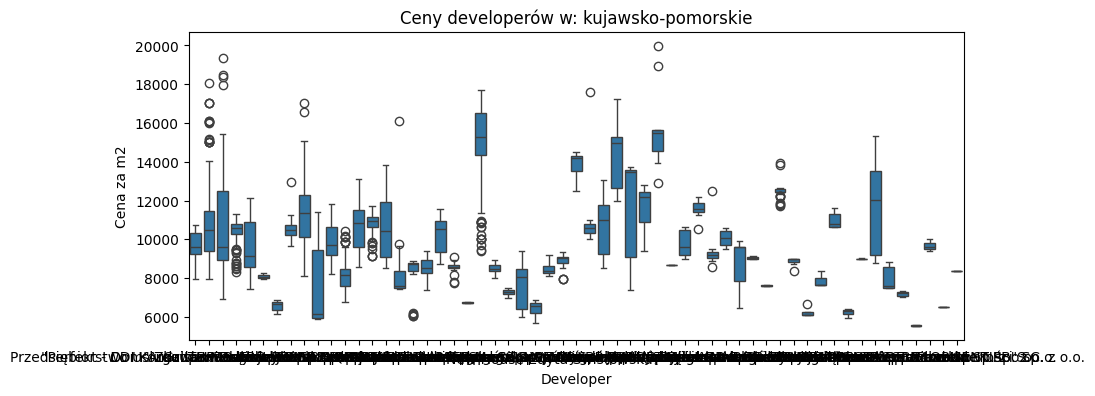

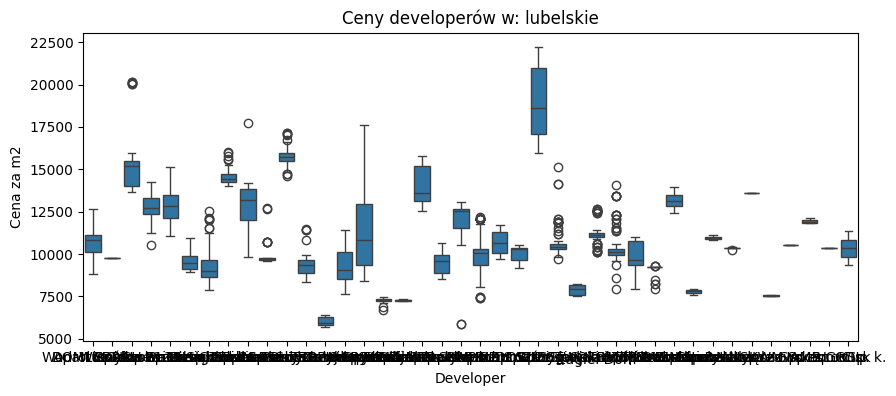

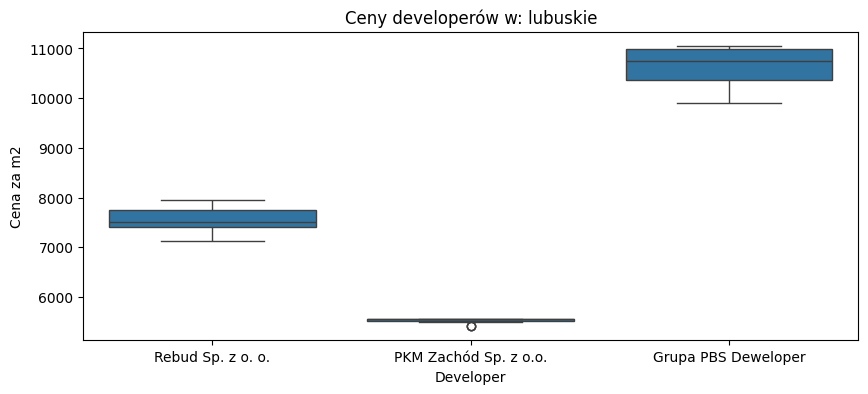

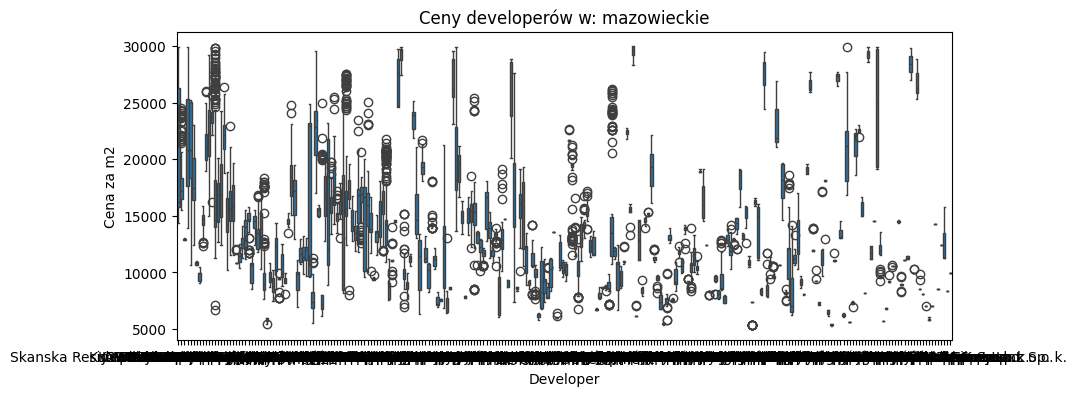

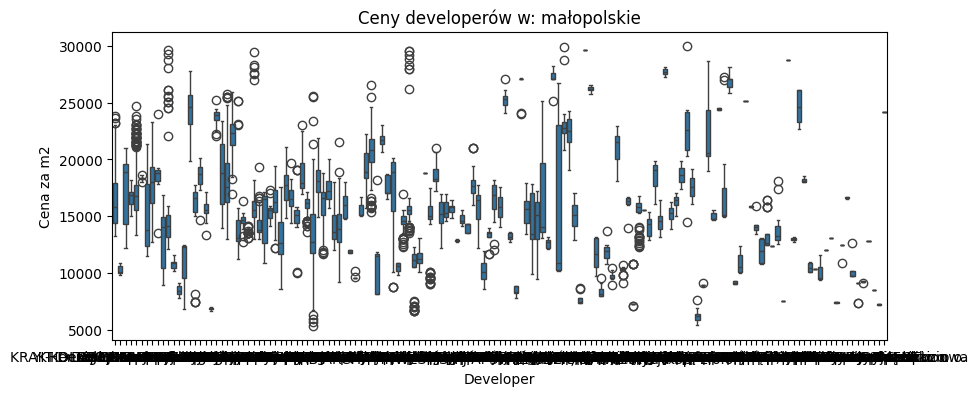

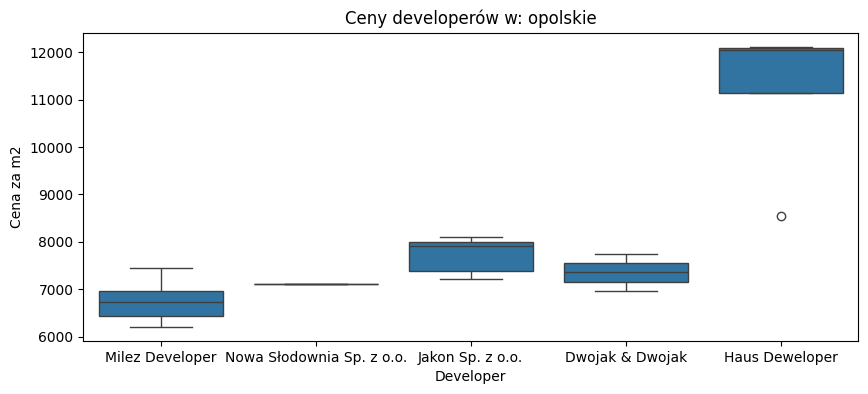

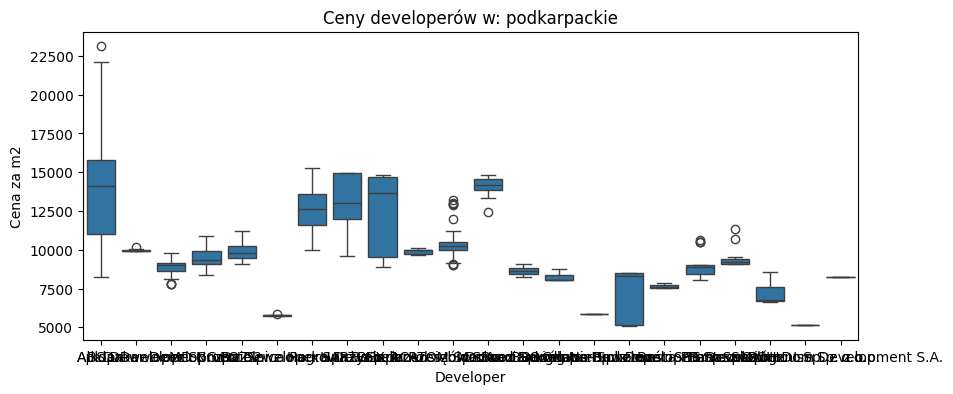

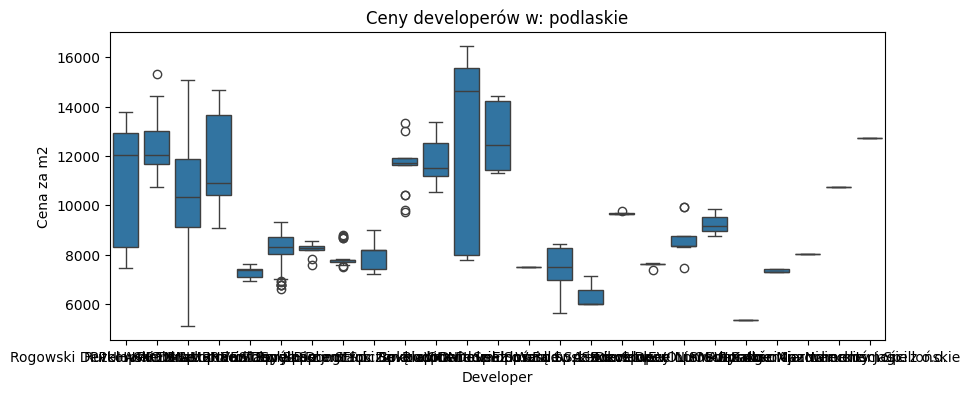

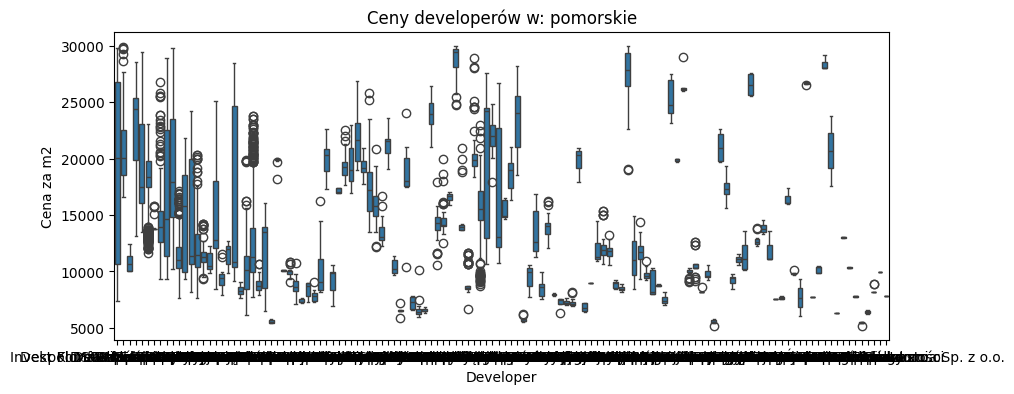

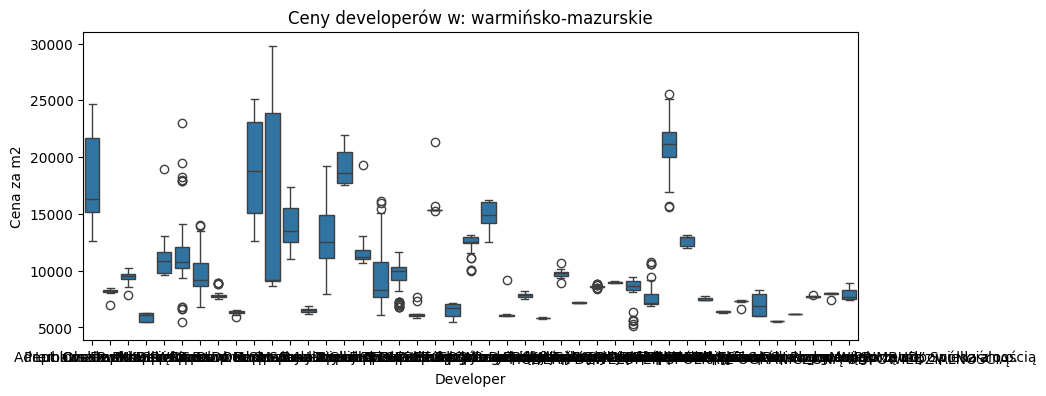

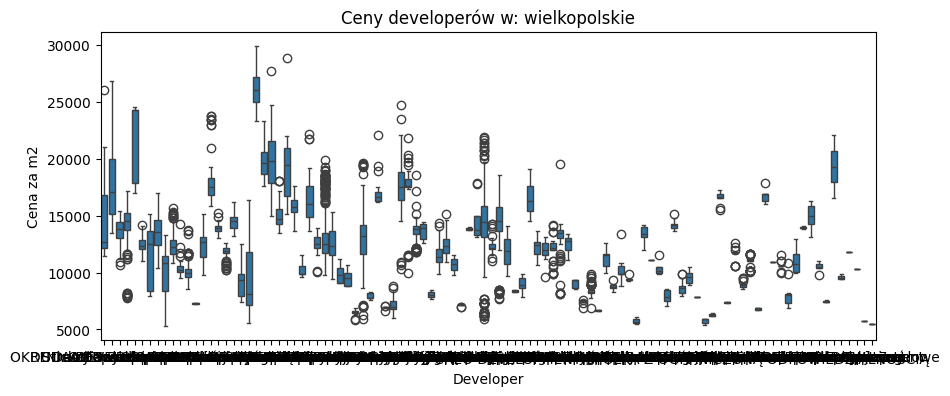

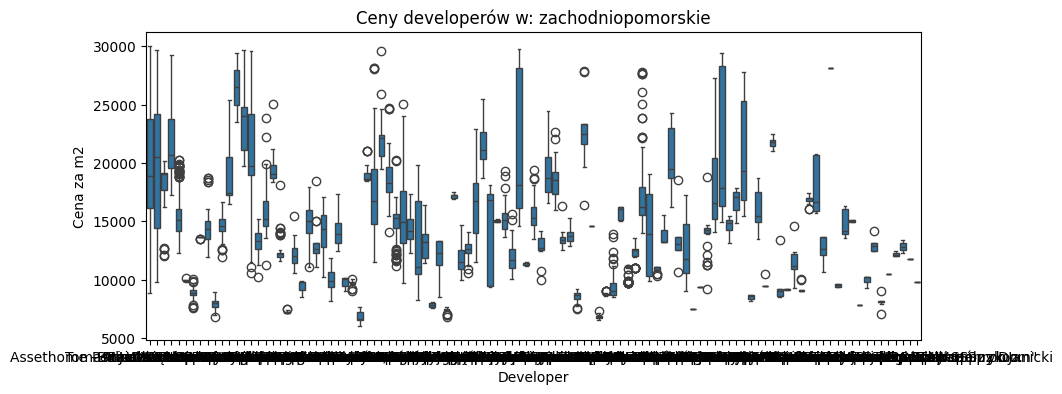

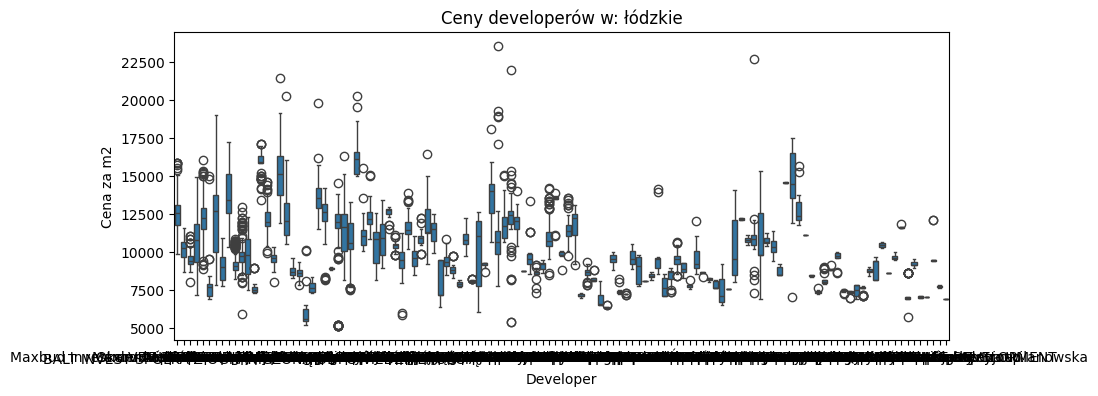

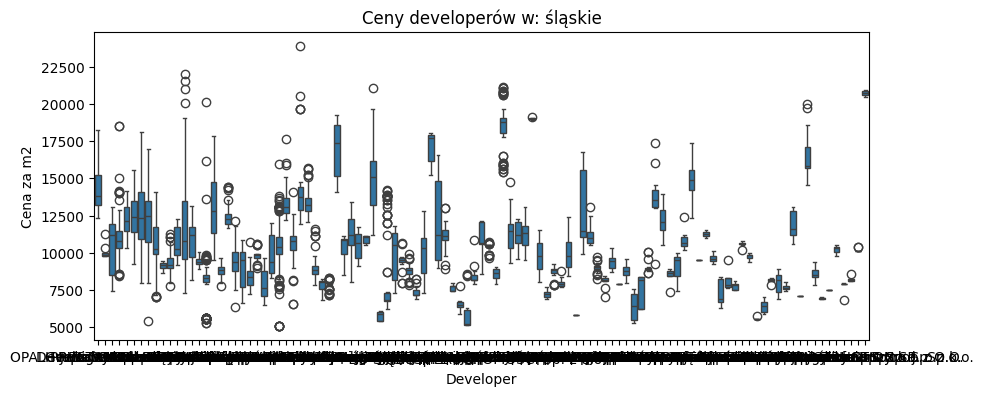

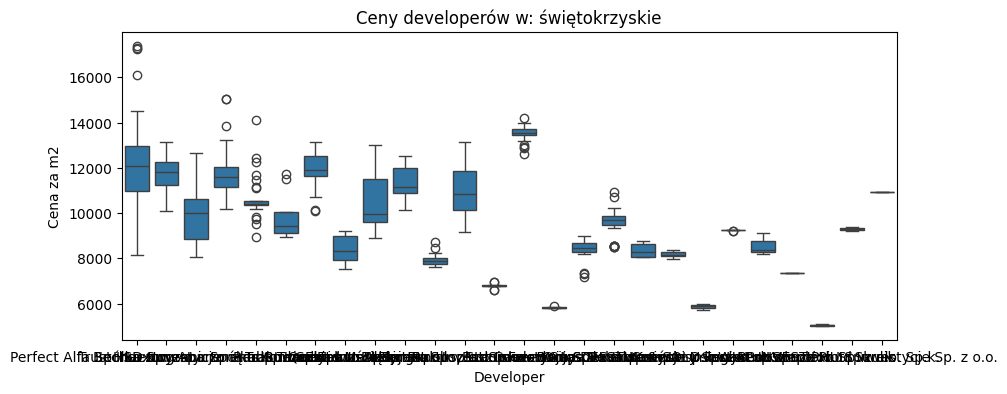

In [18]:
for voivodeship, group_df in df.groupby("voivodeship"):
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=group_df, x="developer", y="price_m2")
    
    plt.title(f"Ceny developerów w: {voivodeship}")
    plt.xlabel("Developer")
    plt.ylabel("Cena za m2")
    plt.show()

In [39]:
df[df["voivodeship"]=='mazowieckie'][["developer","price_m2"]].groupby('developer').mean().sort_values(by="price_m2" ,ascending=False).head(5)
df[df["voivodeship"]=='mazowieckie'][["developer","price_m2"]].groupby('developer').max().sort_values(by="price_m2" ,ascending=False).head(5)
df[df["voivodeship"]=='mazowieckie'][["developer","price_m2"]].groupby('developer').median().sort_values(by="price_m2" ,ascending=False).head(5)

,price_m2
developer,
BPI Real Estate Poland sp. z o.o.,29653.163887
Moderna Holding,29607.482199
Lions Estate,29254.642585
Oaza Mokotów,28448.275862
Ciril,28424.529681


In [47]:
for voivodeship, group_df in df[["developer","price_m2","voivodeship"]].groupby("voivodeship"):
    print("---------------------------------------")
    print(voivodeship)
    print("mean")
    print (group_df[["price_m2","developer"]].groupby('developer').mean().sort_values(by="price_m2" ,ascending=False).head(5))
    print("median")
    print (group_df[["price_m2","developer"]].groupby('developer').median().sort_values(by="price_m2" ,ascending=False).head(5))
    print("max")
    print (group_df[["price_m2","developer"]].groupby('developer').max().sort_values(by="price_m2" ,ascending=False).head(5))

---------------------------------------
dolnośląskie
mean
                                         price_m2
developer                                        
Morris & Lloyd Broker                27491.226366
Toscom Development                   26100.267040
Aries Residence Karpacz Sp. z o. o.  26060.123818
OKRE Development Sp. z o.o.          23177.872155
Nowa Stawowa                         21360.067233
median
                                         price_m2
developer                                        
Morris & Lloyd Broker                27454.780362
Toscom Development                   26564.828159
Aries Residence Karpacz Sp. z o. o.  24691.358025
OKRE Development Sp. z o.o.          23049.823855
Nowa Stawowa                         21351.032065
max
                                                        price_m2
developer                                                       
Aries Residence Karpacz Sp. z o. o.                 29982.964225
Morris & Lloyd Broker               

### jak to jest dla segmentów (floor == -1)? może mają jakieś inne zależności?

In [48]:
df_segment = df[df["is_detached"]==True]

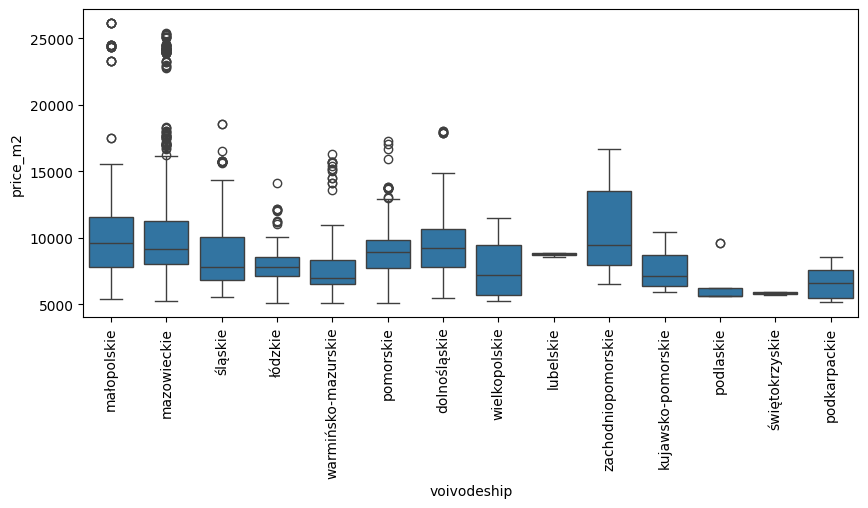

In [54]:
plt.figure(figsize=(10,4))
sns.boxplot( data=df_segment,
    x="voivodeship",
    y="price_m2",
)

plt.xticks(rotation=90)

plt.show()